In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
df = pd.read_csv("drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,53,M,NORMAL,HIGH,32.32,DrugY
1,66,M,NORMAL,NORMAL,23.16,DrugX
2,43,M,NORMAL,HIGH,16.16,DrugX
3,29,F,NORMAL,HIGH,26.54,DrugX
4,57,F,HIGH,HIGH,19.97,DrugA


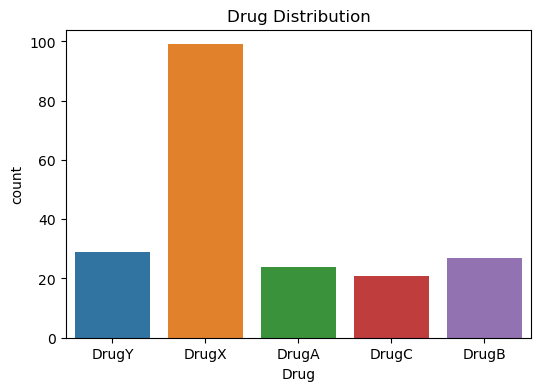

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Drug", data=df)
plt.title("Drug Distribution")
plt.show()

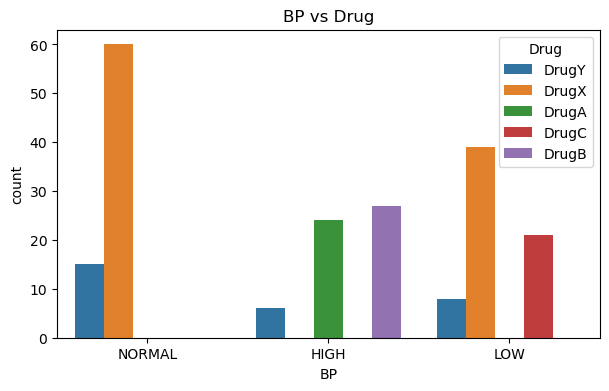

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(x="BP", hue="Drug", data=df)
plt.title("BP vs Drug")
plt.show()

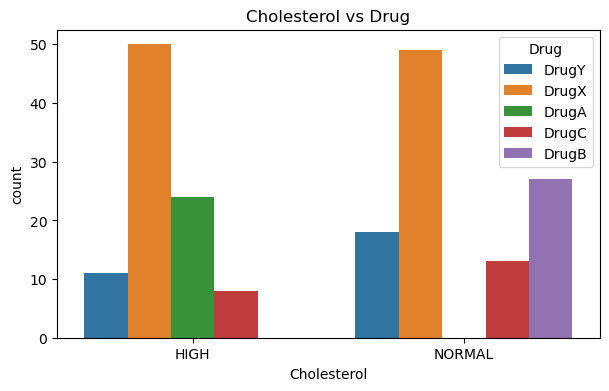

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(x="Cholesterol", hue="Drug", data=df)
plt.title("Cholesterol vs Drug")
plt.show()

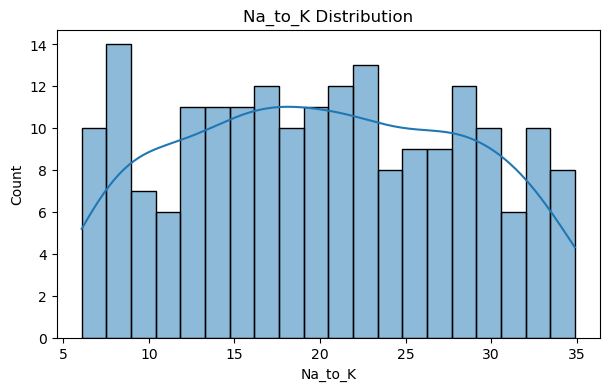

In [20]:
plt.figure(figsize=(7,4))
sns.histplot(df["Na_to_K"], bins=20, kde=True)
plt.title("Na_to_K Distribution")
plt.show()

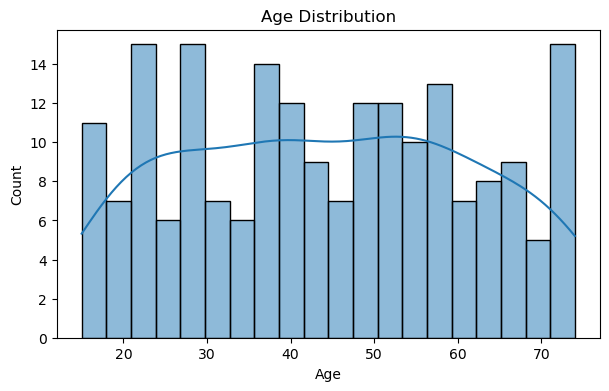

In [21]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

In [22]:
X = df.drop("Drug", axis=1)
y = df["Drug"]

le = LabelEncoder()
y = le.fit_transform(y)

In [12]:
results = {}

for name, model in models.items():
    
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print("\n======================")
    print(name)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.95
[[ 5  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 20  0]
 [ 0  0  0  2  4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         4
           3       0.91      1.00      0.95        20
           4       1.00      0.67      0.80         6

    accuracy                           0.95        40
   macro avg       0.98      0.93      0.95        40
weighted avg       0.95      0.95      0.95        40


Decision Tree
Accuracy: 0.975
[[ 5  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 19  1]
 [ 0  0  0  0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         4
           3       1.00      0.95      0.97  

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
cat_features = ["Sex", "BP", "Cholesterol"]
num_features = ["Age", "Na_to_K"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features)
])

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [26]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "cv_mean": cv_scores.mean()
    }
    
    print("\n", name)
    print("Test Accuracy:", results[name]["accuracy"])
    print("CV Mean Accuracy:", results[name]["cv_mean"])


 Logistic Regression
Test Accuracy: 0.95
CV Mean Accuracy: 0.95625

 Decision Tree
Test Accuracy: 0.975
CV Mean Accuracy: 0.99375

 Random Forest
Test Accuracy: 0.975
CV Mean Accuracy: 0.975

 KNN
Test Accuracy: 0.775
CV Mean Accuracy: 0.83125

 SVM
Test Accuracy: 0.95
CV Mean Accuracy: 0.89375


In [27]:
comparison = pd.DataFrame({
    "Model": results.keys(),
    "Test Accuracy": [results[m]["accuracy"] for m in results],
    "CV Accuracy": [results[m]["cv_mean"] for m in results]
})

comparison.sort_values(by="Test Accuracy", ascending=False)

,Model,Test Accuracy,CV Accuracy
1,Decision Tree,0.975,0.99375
2,Random Forest,0.975,0.97500
0,Logistic Regression,0.950,0.95625
4,SVM,0.950,0.89375
3,KNN,0.775,0.83125


In [28]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20]
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'model__max_depth': None, 'model__n_estimators': 200}
Best Score: 0.9875


In [29]:
best_model = grid.best_estimator_

sample = pd.DataFrame([
    [23, "F", "HIGH", "HIGH", 25.3],
    [45, "M", "LOW", "NORMAL", 10.2],
    [60, "F", "HIGH", "NORMAL", 30.5],
    [30, "M", "NORMAL", "HIGH", 15.0],
    [50, "F", "LOW", "HIGH", 18.7]
], columns=["Age", "Sex", "BP", "Cholesterol", "Na_to_K"])

pred = best_model.predict(sample)

print(le.inverse_transform(pred))

['DrugA' 'DrugC' 'DrugB' 'DrugX' 'DrugX']


In [30]:
# User Input

age = int(input("Enter Age: "))
sex = input("Enter Sex (M/F): ")
bp = input("Enter Blood Pressure (HIGH/NORMAL/LOW): ")
chol = input("Enter Cholesterol (HIGH/NORMAL): ")
na_to_k = float(input("Enter Na_to_K Ratio: "))

# Create DataFrame
user_data = pd.DataFrame({
    "Age": [age],
    "Sex": [sex],
    "BP": [bp],
    "Cholesterol": [chol],
    "Na_to_K": [na_to_k]
})

# Prediction
prediction = best_model.predict(user_data)

# Convert encoded label back to drug name
predicted_drug = le.inverse_transform(prediction)

print("\n================================")
print("Predicted Drug:", predicted_drug[0])
print("================================")

Enter Age: 23
Enter Sex (M/F): F
Enter Blood Pressure (HIGH/NORMAL/LOW): HIGH
Enter Cholesterol (HIGH/NORMAL): HIGH
Enter Na_to_K Ratio: 23.355

Predicted Drug: DrugA
